In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [17]:
weather = pd.read_csv("Documents/cleaned_weather_data.csv")


In [19]:
weather

,City,Region,Latitude,Longitude,Charger Type,Weather Condition,Temperature (°C),Range Impact
0,Varanasi,Uttar Pradesh,34.804413,96.344319,Bharat DC-001,Cold,-1.06,High
1,Vadodara,Gujarat,30.916679,77.683455,CCS,Cold,9.29,High
2,New Delhi,Delhi,27.992432,80.072299,CHAdeMO,Cold,-7.34,High
3,Asansol,West Bengal,15.262391,85.231489,CCS,Hot,35.60,Moderate
4,Vadodara,Gujarat,11.414835,84.992868,CHAdeMO,Hot,44.20,Moderate
...,...,...,...,...,...,...,...,...
995,Kolkata,West Bengal,33.157247,86.566018,CCS,Cold,3.44,High
996,Chennai,Tamil Nadu,12.117468,91.858268,CCS,Cold,4.30,High
997,Jaipur,Rajasthan,14.480333,88.255885,CHAdeMO,Moderate,19.77,Low
998,Kolkata,West Bengal,10.067443,81.530853,CHAdeMO,Moderate,22.47,Low


In [23]:
weather.shape

(1000, 8)

In [25]:
weather.isnull().sum()

City                 0
Region               0
Latitude             0
Longitude            0
Charger Type         0
Weather Condition    0
Temperature (°C)     0
Range Impact         0
dtype: int64

In [126]:
# Function to removce outlier from multiple columns
def remove_outliers_iqr_multi(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        
    for col in columns:
        sns.boxplot(y=df_clean[col])
        plt.title(f'Boxplot of {col} (Outliers Removed)')
        plt.show()
    return df_clean

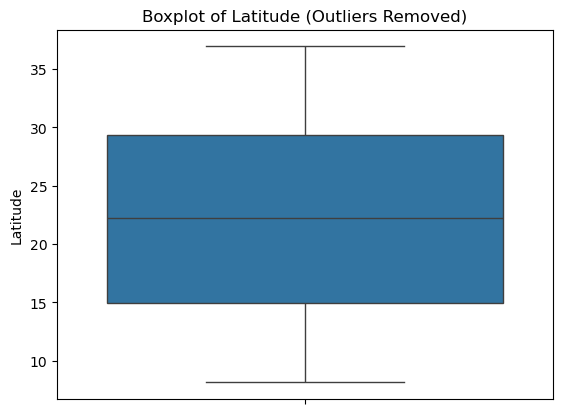

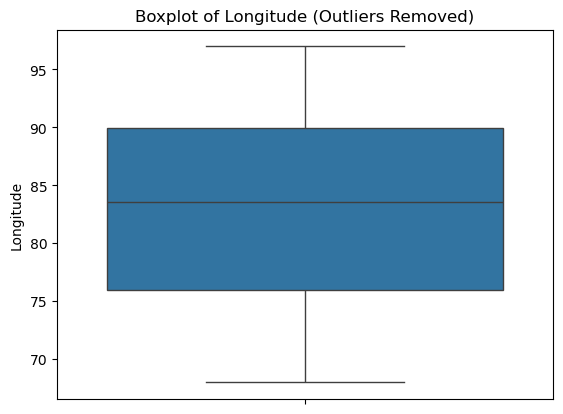

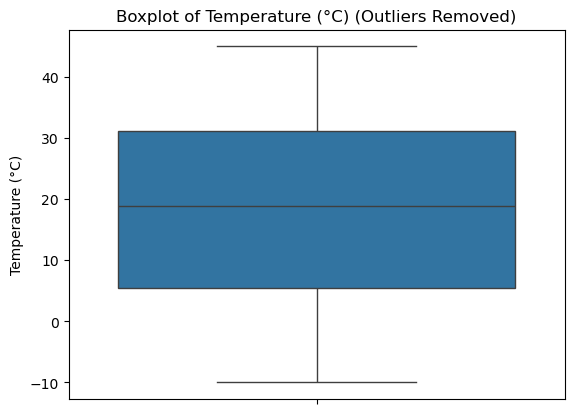

In [134]:

num_col = ['Latitude','Longitude','Temperature (°C)']
weather = remove_outliers_iqr_multi(weather, num_col)

In [136]:
weather.columns

Index(['City', 'Region', 'Latitude', 'Longitude', 'Charger Type',
       'Weather Condition', 'Temperature (°C)', 'Range Impact'],
      dtype='object')

## Encoding 

In [138]:
from sklearn.preprocessing import LabelEncoder 
lr = LabelEncoder()

In [140]:
li =  weather.select_dtypes(exclude= ['int64','float64']).columns
for i in li:
    le = LabelEncoder()
    weather[i] = le.fit_transform(weather[i])

In [142]:
# data is converted into 0's and 1's 
weather.columns

Index(['City', 'Region', 'Latitude', 'Longitude', 'Charger Type',
       'Weather Condition', 'Temperature (°C)', 'Range Impact'],
      dtype='object')

In [73]:
'''Predict Charger Type (CHAdeMO / CCS / Bharat DC-001 / Type-2)
Type: Multi-class Classification

Possible features:

Weather Condition

Temperature

Region

Range Impact
'''


'Predict Charger Type (CHAdeMO / CCS / Bharat DC-001 / Type-2)\nType: Multi-class Classification\n\nPossible features:\n\nWeather Condition\n\nTemperature\n\nRegion\n\nRange Impact\n'

In [144]:
# Divide data into X and Y 
X = weather[['Weather Condition','Temperature (°C)','Region','Range Impact']].values
Y = weather['Charger Type'].values

In [146]:
X

array([[ 0.  , -1.06,  8.  ,  0.  ],
       [ 0.  ,  9.29,  1.  ,  0.  ],
       [ 0.  , -7.34,  0.  ,  0.  ],
       ...,
       [ 2.  , 19.77,  6.  ,  1.  ],
       [ 2.  , 22.47,  9.  ,  1.  ],
       [ 0.  , -2.14,  2.  ,  0.  ]])

In [148]:
Y

array([0, 1, 2, 1, 2, 3, 0, 1, 2, 1, 2, 0, 1, 0, 1, 2, 0, 2, 2, 2, 1, 0,
       0, 0, 3, 2, 0, 0, 1, 2, 3, 3, 2, 2, 1, 0, 1, 1, 3, 2, 1, 0, 2, 1,
       0, 1, 3, 0, 1, 1, 3, 2, 0, 2, 2, 3, 0, 3, 3, 0, 1, 3, 2, 1, 1, 1,
       1, 0, 1, 3, 2, 3, 3, 2, 1, 2, 0, 1, 2, 1, 1, 1, 1, 0, 0, 3, 3, 3,
       3, 0, 3, 1, 0, 1, 2, 1, 0, 3, 0, 1, 3, 1, 1, 2, 2, 2, 1, 3, 1, 0,
       2, 1, 1, 1, 0, 0, 0, 1, 0, 1, 2, 2, 0, 2, 2, 1, 0, 1, 2, 1, 0, 3,
       2, 2, 0, 3, 2, 0, 0, 1, 2, 3, 2, 0, 2, 2, 2, 1, 2, 1, 1, 2, 1, 1,
       0, 2, 3, 2, 3, 0, 3, 3, 1, 3, 1, 0, 1, 0, 3, 1, 1, 1, 1, 3, 0, 3,
       2, 3, 1, 0, 2, 1, 3, 1, 1, 3, 0, 1, 1, 2, 2, 3, 0, 1, 2, 3, 1, 2,
       3, 1, 2, 0, 0, 1, 0, 2, 0, 0, 2, 3, 1, 3, 3, 1, 0, 0, 1, 3, 3, 2,
       3, 2, 2, 3, 0, 3, 0, 1, 1, 2, 3, 0, 2, 2, 0, 2, 0, 1, 0, 3, 1, 2,
       2, 0, 1, 2, 3, 1, 1, 3, 3, 1, 1, 2, 3, 2, 2, 2, 0, 3, 0, 2, 1, 2,
       2, 3, 3, 0, 0, 2, 3, 2, 0, 0, 2, 0, 1, 1, 1, 0, 0, 0, 3, 3, 3, 2,
       1, 0, 2, 3, 0, 1, 2, 2, 0, 3, 3, 0, 3, 1, 0,

In [150]:
from sklearn.model_selection import train_test_split

In [152]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size= 0.3, random_state= 10)

# Optional: Confirm shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (700, 4)
X_test shape: (300, 4)
y_train shape: (700,)
y_test shape: (300,)


## STANDARD SCALING 

In [155]:
from sklearn.preprocessing import StandardScaler 
sc = StandardScaler()

In [157]:
''' 
fit_transform() = fit() + transform()
fit() → Learns patterns from the data (like mean, standard deviation, encoding rules, etc.)
transform() → Applies those learned patterns to convert or modify the data'''

' \nfit_transform() = fit() + transform()\nfit() → Learns patterns from the data (like mean, standard deviation, encoding rules, etc.)\ntransform() → Applies those learned patterns to convert or modify the data'

In [159]:
X_train = sc.fit_transform(X_train)

In [161]:
X_train

array([[-0.00891898,  1.10776822,  0.84389662,  1.16760297],
       [-0.00891898,  1.70776201, -0.54116231,  1.16760297],
       [-1.25757588, -0.94390824,  0.84389662, -1.26852841],
       ...,
       [-1.25757588, -0.95968026,  0.84389662, -1.26852841],
       [ 1.23973793,  0.05235746,  1.19016135, -0.05046272],
       [-0.00891898,  0.58532018, -1.23369178,  1.16760297]])

In [163]:
X_test = sc.transform(X_test)

In [165]:
X_test

array([[ 1.23973793, -0.47337642, -0.19489758, -0.05046272],
       [-1.25757588, -0.91499288,  0.49763189, -1.26852841],
       [-0.00891898,  1.2148865 , -1.23369178,  1.16760297],
       ...,
       [-1.25757588, -0.78684524, -0.19489758, -1.26852841],
       [ 1.23973793,  0.01424176,  1.53642608, -0.05046272],
       [-1.25757588, -0.62649641, -1.57995651, -1.26852841]])

In [167]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()


In [169]:
lr.fit(X_train , y_train)

LogisticRegression()

In [189]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [191]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [193]:
y_pred = model.predict(X_test)

In [195]:
y_pred

array([2, 3, 0, 2, 3, 2, 1, 2, 0, 1, 1, 1, 3, 1, 3, 1, 0, 1, 2, 3, 2, 0,
       1, 2, 1, 0, 1, 1, 0, 3, 2, 2, 0, 0, 1, 0, 3, 1, 1, 2, 1, 2, 0, 3,
       0, 0, 3, 2, 3, 2, 0, 3, 3, 0, 0, 0, 2, 2, 1, 3, 1, 2, 3, 0, 2, 0,
       0, 2, 3, 0, 2, 2, 1, 0, 3, 2, 3, 2, 3, 1, 0, 1, 1, 2, 0, 3, 1, 3,
       3, 2, 0, 3, 1, 1, 2, 2, 3, 1, 2, 3, 3, 2, 0, 1, 2, 0, 2, 0, 3, 2,
       1, 0, 0, 0, 3, 2, 3, 0, 2, 3, 2, 3, 1, 3, 2, 3, 1, 3, 2, 1, 0, 2,
       3, 3, 1, 3, 3, 1, 1, 0, 1, 0, 1, 3, 2, 0, 0, 3, 0, 2, 2, 3, 2, 2,
       3, 1, 0, 0, 1, 3, 1, 2, 0, 2, 0, 0, 3, 0, 0, 3, 1, 3, 2, 1, 2, 2,
       2, 0, 0, 0, 0, 3, 2, 1, 1, 1, 1, 1, 2, 1, 0, 1, 2, 1, 2, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 2, 3, 0, 3, 1, 3, 2, 1, 0, 3, 3, 0, 3, 0,
       0, 0, 1, 3, 3, 2, 2, 0, 1, 2, 0, 2, 0, 0, 1, 1, 3, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 2, 2, 2, 2, 3, 0, 1, 2, 2, 1, 1, 3, 3, 0, 2, 1, 2, 3,
       3, 2, 1, 0, 2, 3, 3, 0, 2, 2, 3, 3, 1, 2, 2, 2, 3, 3, 1, 0, 1, 0,
       2, 3, 1, 0, 0, 2, 2, 3, 0, 3, 1, 3, 2, 0], d

In [197]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.26666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.24      0.22        70
           1       0.26      0.27      0.26        67
           2       0.22      0.20      0.21        87
           3       0.40      0.37      0.38        76

    accuracy                           0.27       300
   macro avg       0.27      0.27      0.27       300
weighted avg       0.27      0.27      0.27       300


Confusion Matrix:
 [[17 20 19 14]
 [20 18 16 13]
 [30 25 17 15]
 [16  7 25 28]]


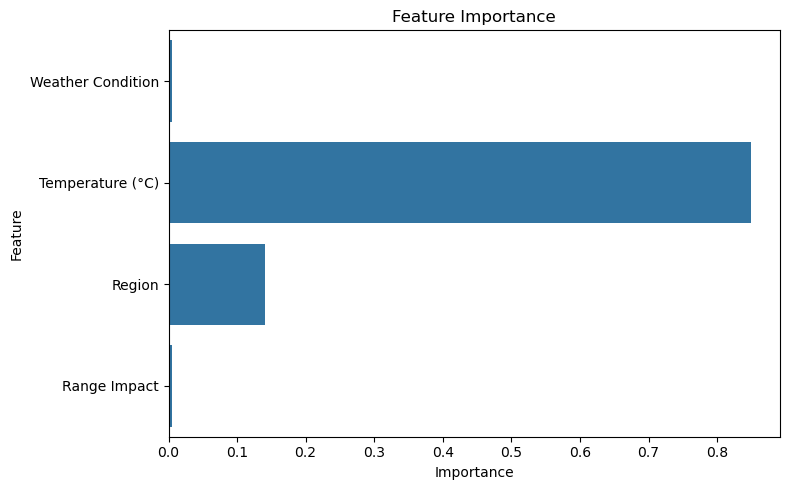

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features and target
X = weather[['Weather Condition','Temperature (°C)','Region','Range Impact']]
Y = weather['Charger Type']
# Fit the model
model.fit(X, Y)

# Get importances
importances = model.feature_importances_
feat_names = X.columns

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
